<a href="https://colab.research.google.com/github/jacunda/POS-DATASCIENCE-IA/blob/main/ComputerVisionl/TrabalhoFinalComputerVisionV1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

O setor de fraudes apontou que existem clientes que se queixaram de não contratar serviços específicos, como o crédito pessoal. No entanto, os protocolos de segurança da senha foram realizados em conformidade, cada cliente autenticou com sua própria senha.​ Em função disso, o banco precisa arcar com reembolsos e medidas de contenção para evitar processos judiciais, pois os clientes alegam terem sido invadidos por hackers ou algo similar.​

Além da senha, podemos implementar formas de autenticação complementares, a depender do serviço, que utilizasse uma verificação e identificação facial. Caso o cliente não seja autenticado, ele será atendido por uma esteira dedicada e as evidências da não identificação serão encaminhadas para a área de IA para validação dos parâmetros e limiares para aperfeiçoamento do modelo.

Será necessário construir:​

Detector de faces​
Identificação de faces​
Detecção de vivacidade (liveness) para evitar que um fraudador utilize uma foto estática.

In [1]:
!apt-get install -y libopencv-dev

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  at-spi2-core gsettings-desktop-schemas gstreamer1.0-plugins-base
  libatk-bridge2.0-0 libatk1.0-0 libatk1.0-data libatspi2.0-0 libavcodec-dev
  libavformat-dev libavutil-dev libcdparanoia0 libcharls2 libdc1394-dev
  libdouble-conversion3 libexif-dev libexif-doc libexif12 libgdcm-dev
  libgdcm3.0 libgl2ps1.4 libglew2.2 libgphoto2-6 libgphoto2-dev
  libgphoto2-l10n libgphoto2-port12 libgstreamer-plugins-base1.0-0 libgtk-3-0
  libgtk-3-bin libgtk-3-common libilmbase-dev libilmbase25
  libopencv-calib3d-dev libopencv-calib3d4.5d libopencv-contrib-dev
  libopencv-contrib4.5d libopencv-core-dev libopencv-core4.5d
  libopencv-dnn-dev libopencv-dnn4.5d libopencv-features2d-dev
  libopencv-features2d4.5d libopencv-flann-dev libopencv-flann4.5d
  libopencv-highgui-dev libopencv-highgui4.5d libopencv-imgcodecs-dev
  libopencv-imgcodecs4.5d libopen

In [2]:
import numpy as np
import pandas as pd
import glob
from tqdm import tqdm
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import math
import time
import IPython

from IPython.display import display, Javascript, HTML
from google.colab.output import eval_js
from base64 import b64decode, b64encode


# Scikit learn


#Exibição na mesma tela do Jupyter
%matplotlib inline

import datetime
import dlib

from scipy.spatial import distance as dist

In [3]:
# ============================================================
# PASSO 2 — Download dos modelos (robusto)
# Execute após reiniciar o kernel (após o PASSO 1).
# ============================================================
import os
import ssl
import urllib.request
from pathlib import Path

os.makedirs("models", exist_ok=True)
os.makedirs("data/enroll", exist_ok=True)
os.makedirs("data/test", exist_ok=True)
os.makedirs("evidencias", exist_ok=True)

MODEL_URLS = {
    "face_landmarker.task": (
        "https://storage.googleapis.com/mediapipe-models/face_landmarker/"
        "face_landmarker/float16/1/face_landmarker.task"
    ),
    "face_detection_yunet_2023mar.onnx": (
        "https://github.com/opencv/opencv_zoo/raw/main/models/"
        "face_detection_yunet/face_detection_yunet_2023mar.onnx"
    ),
    "face_recognition_sface_2021dec.onnx": (
        "https://github.com/opencv/opencv_zoo/raw/main/models/"
        "face_recognition_sface/face_recognition_sface_2021dec.onnx"
    ),
}

def _download_with_urllib(url: str, dst_path: Path):
    # Fallback para ambientes com problema de certificado SSL
    try:
        urllib.request.urlretrieve(url, str(dst_path))
    except Exception:
        ctx = ssl._create_unverified_context()
        with urllib.request.urlopen(url, context=ctx, timeout=60) as response, open(dst_path, "wb") as out:
            out.write(response.read())

def _download_with_requests(url: str, dst_path: Path):
    import requests
    with requests.get(url, stream=True, timeout=60) as r:
        r.raise_for_status()
        with open(dst_path, "wb") as f:
            for chunk in r.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    f.write(chunk)

def download_file(url: str, dst_path: Path):
    if dst_path.exists() and dst_path.stat().st_size > 0:
        return "cached"

    try:
        _download_with_urllib(url, dst_path)
    except Exception as err_urllib:
        try:
            _download_with_requests(url, dst_path)
        except Exception as err_requests:
            raise RuntimeError(
                f"Falha ao baixar {dst_path.name}\n"
                f"urllib: {err_urllib}\n"
                f"requests: {err_requests}"
            )

    if not dst_path.exists() or dst_path.stat().st_size == 0:
        raise RuntimeError(f"Download inválido: {dst_path.name} ficou vazio.")

    return "downloaded"


print("Iniciando download dos modelos...\n")
for model_name, url in MODEL_URLS.items():
    dst = Path("models") / model_name
    status = download_file(url, dst)
    size_kb = dst.stat().st_size // 1024
    flag = "✅" if status in {"cached", "downloaded"} else "⚠️"
    print(f"{flag} {model_name} ({size_kb} KB) - {status}")

print("\nModelos disponíveis em ./models:")
for f in sorted(os.listdir("models")):
    size_kb = os.path.getsize(f"models/{f}") // 1024
    print(f"   - {f} ({size_kb} KB)")


Iniciando download dos modelos...

✅ face_landmarker.task (3670 KB) - downloaded
✅ face_detection_yunet_2023mar.onnx (227 KB) - downloaded
✅ face_recognition_sface_2021dec.onnx (37789 KB) - downloaded

Modelos disponíveis em ./models:
   - face_detection_yunet_2023mar.onnx (227 KB)
   - face_landmarker.task (3670 KB)
   - face_recognition_sface_2021dec.onnx (37789 KB)


In [4]:
# ============================================================
# Funções de captura — Webcam (Opção A) e Upload de arquivo (Opção B)
# Baseado no padrão do professor para Google Colab
# ============================================================

import IPython.display as display
import base64

try:
    from google.colab import output as colab_output
    from google.colab import files as colab_files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    class _FallbackOutput:
        @staticmethod
        def eval_js(*args, **kwargs):
            raise EnvironmentError(
                "google.colab não está disponível. Execute no Google Colab."
            )
    class _FallbackFiles:
        @staticmethod
        def upload():
            raise EnvironmentError(
                "google.colab.files não está disponível. Execute no Google Colab."
            )
    colab_output = _FallbackOutput()
    colab_files  = _FallbackFiles()


# ─────────────────────────────────────────────────────────────────
# OPÇÃO A — Webcam: captura foto única
# ─────────────────────────────────────────────────────────────────
def take_photo(filename: str, quality: float = 0.8) -> str:
    """Ativa a webcam do navegador e salva foto ao clicar no botão."""
    js = """
    async function capturePhoto(quality) {
        return new Promise((resolve, reject) => {
            const div = document.createElement('div');
            document.body.appendChild(div);
            const video = document.createElement('video');
            video.style.cssText = 'width:100%;max-width:640px;height:auto;';
            div.appendChild(video);
            navigator.mediaDevices.getUserMedia({ video: true }).then(stream => {
                video.srcObject = stream;
                video.play();
                const button = document.createElement('button');
                button.innerText = '📷 Capturar Foto';
                button.style.cssText = 'display:block;margin-top:10px;padding:10px;font-size:16px;cursor:pointer;background:red;color:white;';
                div.appendChild(button);
                button.onclick = () => {
                    const canvas = document.createElement('canvas');
                    canvas.width = video.videoWidth;
                    canvas.height = video.videoHeight;
                    canvas.getContext('2d').drawImage(video, 0, 0);
                    stream.getTracks().forEach(t => t.stop());
                    div.remove();
                    resolve(canvas.toDataURL('image/jpeg', quality));
                };
            }).catch(err => { div.remove(); reject(err); });
        });
    }
    """
    parent = os.path.dirname(filename)
    if parent:
        os.makedirs(parent, exist_ok=True)
    display.display(display.Javascript(js))
    data_url = colab_output.eval_js(f'capturePhoto({quality})')
    if not data_url or ',' not in data_url:
        raise ValueError("Nenhuma imagem capturada. Tente novamente.")
    encoded = data_url.split(',')[1]
    encoded += '=' * (-len(encoded) % 4)
    image = cv2.imdecode(np.frombuffer(base64.b64decode(encoded), np.uint8), cv2.IMREAD_COLOR)
    if image is None:
        raise ValueError("OpenCV falhou ao decodificar a imagem.")
    cv2.imwrite(filename, image)
    print(f"📷 Foto salva em: {filename}")
    return filename


# ─────────────────────────────────────────────────────────────────
# OPÇÃO A — Webcam: captura sequência de frames para liveness
# ─────────────────────────────────────────────────────────────────
def capture_frames(n_frames: int = 25, interval_ms: int = 150, quality: float = 0.7) -> list:
    """Captura N frames com contagem regressiva e instrução para piscar."""
    js = f"""
    async function captureFrames(nFrames, intervalMs, quality) {{
        return new Promise((resolve, reject) => {{
            const div = document.createElement('div');
            document.body.appendChild(div);
            const label = document.createElement('p');
            label.style.cssText = 'font-size:18px;font-weight:bold;color:#333;';
            label.innerText = '👁 Olhe para a câmera e PISCE os olhos quando solicitado!';
            div.appendChild(label);
            const video = document.createElement('video');
            video.style.cssText = 'width:100%;max-width:640px;';
            div.appendChild(video);
            const countdown = document.createElement('p');
            countdown.style.cssText = 'font-size:24px;font-weight:bold;color:red;';
            div.appendChild(countdown);
            navigator.mediaDevices.getUserMedia({{ video: true }}).then(stream => {{
                video.srcObject = stream;
                video.play().then(() => {{
                    let count = 3;
                    countdown.innerText = 'Iniciando em: ' + count + 's';
                    const tick = setInterval(() => {{
                        count--;
                        if (count > 0) {{ countdown.innerText = 'Iniciando em: ' + count + 's'; }}
                        else {{
                            clearInterval(tick);
                            countdown.innerText = '🔴 Gravando... PISCE AGORA!';
                            const frames = []; let captured = 0;
                            const ci = setInterval(() => {{
                                const canvas = document.createElement('canvas');
                                canvas.width = video.videoWidth;
                                canvas.height = video.videoHeight;
                                canvas.getContext('2d').drawImage(video, 0, 0);
                                frames.push(canvas.toDataURL('image/jpeg', quality));
                                captured++;
                                countdown.innerText = '🔴 Gravando... ' + captured + '/' + nFrames;
                                if (captured >= nFrames) {{
                                    clearInterval(ci);
                                    stream.getTracks().forEach(t => t.stop());
                                    div.remove(); resolve(frames);
                                }}
                            }}, intervalMs);
                        }}
                    }}, 1000);
                }});
            }}).catch(err => {{ div.remove(); reject(err); }});
        }});
    }}
    """
    display.display(display.Javascript(js))
    data_urls = colab_output.eval_js(f'captureFrames({n_frames}, {interval_ms}, {quality})')
    frames_bgr = []
    for du in data_urls:
        if not du or ',' not in du:
            continue
        enc = du.split(',')[1]
        enc += '=' * (-len(enc) % 4)
        img = cv2.imdecode(np.frombuffer(base64.b64decode(enc), np.uint8), cv2.IMREAD_COLOR)
        if img is not None:
            frames_bgr.append(img)
    print(f"✅ {len(frames_bgr)} frames capturados para liveness.")
    return frames_bgr


# ─────────────────────────────────────────────────────────────────
# OPÇÃO B — Upload: foto para identificação
# ─────────────────────────────────────────────────────────────────
def upload_photo(save_path: str) -> str:
    """Solicita upload de uma imagem (JPG/PNG) e salva no caminho indicado."""
    print("📁 Selecione uma foto (JPG/PNG) para identificação...")
    uploaded = colab_files.upload()
    if not uploaded:
        raise ValueError("Nenhum arquivo enviado.")
    fname, data = next(iter(uploaded.items()))
    os.makedirs(os.path.dirname(save_path) or ".", exist_ok=True)
    with open(save_path, "wb") as f:
        f.write(data)
    print(f"✅ Foto salva em: {save_path}")
    return save_path


# ─────────────────────────────────────────────────────────────────
# OPÇÃO B — Upload: vídeo para liveness (extrai frames)
# ─────────────────────────────────────────────────────────────────
def upload_video_and_extract_frames(max_frames: int = 40) -> list:
    """
    Solicita upload de um vídeo curto (MP4/AVI/MOV) e extrai até max_frames
    frames uniformemente espaçados para análise de liveness.
    Recomendação: vídeo de 2-4 segundos onde você pisce pelo menos uma vez.
    """
    print("📁 Selecione um vídeo (MP4/AVI/MOV) — 2 a 4 segundos, pisque durante a gravação...")
    uploaded = colab_files.upload()
    if not uploaded:
        raise ValueError("Nenhum arquivo enviado.")
    fname, data = next(iter(uploaded.items()))
    # Salva temporariamente para leitura com cv2
    tmp_path = f"/tmp/{fname}"
    with open(tmp_path, "wb") as f:
        f.write(data)

    cap   = cv2.VideoCapture(tmp_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    step  = max(1, total // max_frames)
    frames, idx = [], 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        if idx % step == 0:
            frames.append(frame)
        idx += 1
        if len(frames) >= max_frames:
            break
    cap.release()
    try:
        os.remove(tmp_path)
    except OSError:
        pass

    print(f"✅ {len(frames)} frames extraídos de '{fname}' (total no vídeo: {total}).")
    return frames


In [4]:
import os
# Criando a estrutura de pastas necessária
os.makedirs('data/enroll/cliente_teste', exist_ok=True)
os.makedirs('data/test', exist_ok=True)
print('Pastas criadas! Agora siga para o próximo passo.')

Pastas criadas! Agora siga para o próximo passo.


In [ ]:
%ls

data/  evidencias/  models/  sample_data/


In [6]:
import os
import cv2
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
from scipy.spatial import distance as dist

# MediaPipe: Tasks API (FaceLandmarker) — padrão do professor

# Aliases no estilo do professor (aula 4)


# ── Caminhos ────────────────────────────────────────────────
BASE_DIR        = Path.cwd()
MODEL_DIR       = BASE_DIR / "models"
DATA_DIR        = BASE_DIR / "data"
ENROLL_DIR      = DATA_DIR / "enroll"
TEST_DIR        = DATA_DIR / "test"
EVIDENCE_DIR    = BASE_DIR / "evidencias"
LANDMARKER_PATH = MODEL_DIR / "face_landmarker.task"

for d in [MODEL_DIR, EVIDENCE_DIR, ENROLL_DIR, TEST_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Diretório base      : {BASE_DIR}")
print(f"Modelo liveness     : {LANDMARKER_PATH}  {'✅' if LANDMARKER_PATH.exists() else '❌ não encontrado'}")

cv2_version_str = "unknown"
try:
    cv2_version_str = cv2.__version__
except AttributeError:
    cv2_version_str = "VERSION_NOT_AVAILABLE"
    print("⚠️  Warning: cv2.__version__ attribute is not available.")

print(f"numpy={np.__version__}  cv2={cv2_version_str} ")# mediapipe={mp.#__version__}")


Diretório base      : /content
Modelo liveness     : /content/models/face_landmarker.task  ✅
numpy=2.0.2  cv2=4.13.0 


# Solução proposta para o trabalho

Arquitetura escolhida: **YuNet** (detecção) + **SFace** (identificação) + **FaceLandmarker Tasks API** (liveness).

| Componente | Modelo | Finalidade |
|---|---|---|
| Detecção de faces | YuNet (OpenCV Zoo) | Localiza e recorta faces na imagem |
| Identificação facial | SFace (OpenCV Zoo) | Gera embedding e compara por similaridade de cosseno |
| Liveness (vivacidade) | face_landmarker.task (MediaPipe) | Detecta piscadas via EAR com a Tasks API |

## Por que essa arquitetura?
- **YuNet**: excelente equilíbrio entre velocidade e precisão em CPU; roda bem no Colab.
- **SFace**: gera embeddings de 128 dimensões robustos para comparação 1:N por cosseno.
- **FaceLandmarker (Tasks API)**: modelo oficial do Google/MediaPipe para 478 landmarks faciais com alta precisão nos pontos dos olhos — ideal para EAR.

## Fluxo de autenticação do banco

```
Cadastro (Enrollment)         Autenticação
─────────────────────         ──────────────────────────────────────
N fotos do cliente    →  galeria  →  comparação SFace (cosseno)  ┐
                                                                   ├→ APROVADO / EM_REVISAO
vídeo/webcam frames   →  EAR      →  piscada detectada          ┘
```

## Saídas entregues
- `APROVADO`: identidade confirmada (score ≥ threshold) **E** liveness aprovado (piscada detectada).
- `EM_REVISAO`: falha na identificação **ou** na vivacidade → imagem + JSON encaminhados para área de IA/Fraudes.


In [7]:
# ============================================================
# Verificação / fallback dos modelos
# Os modelos devem ter sido baixados no PASSO 2 (wget).
# Esta célula faz o fallback por urllib caso algum esteja faltando.
# ============================================================
import urllib.request

yunet_path = MODEL_DIR / "face_detection_yunet_2023mar.onnx"
sface_path = MODEL_DIR / "face_recognition_sface_2021dec.onnx"

_URLS = {
    yunet_path: (
        "https://github.com/opencv/opencv_zoo/raw/main/models/"
        "face_detection_yunet/face_detection_yunet_2023mar.onnx"
    ),
    sface_path: (
        "https://github.com/opencv/opencv_zoo/raw/main/models/"
        "face_recognition_sface/face_recognition_sface_2021dec.onnx"
    ),
    LANDMARKER_PATH: (
        "https://storage.googleapis.com/mediapipe-models/face_landmarker/"
        "face_landmarker/float16/1/face_landmarker.task"
    ),
}

for dst, url in _URLS.items():
    if dst.exists():
        print(f"[OK] {dst.name}")
    else:
        print(f"Baixando via urllib: {dst.name} ...")
        urllib.request.urlretrieve(url, dst)
        print(f"[OK] Salvo: {dst.name}")

assert yunet_path.exists(),       "❌ YuNet não encontrado."
assert sface_path.exists(),       "❌ SFace não encontrado."
assert LANDMARKER_PATH.exists(),  "❌ FaceLandmarker não encontrado."
print("\n✅ Todos os modelos estão prontos.")


[OK] face_detection_yunet_2023mar.onnx
[OK] face_recognition_sface_2021dec.onnx
[OK] face_landmarker.task

✅ Todos os modelos estão prontos.


In [8]:
# ============================================================
# Inicialização dos modelos e funções utilitárias
# ============================================================
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Verifique se o opencv-contrib está disponível.
# Se esta célula falhar, vá em Ambiente de Execução -> Reiniciar Sessão.

try:
    # Cria detector YuNet
    detector = cv2.FaceDetectorYN.create(
        model=str(yunet_path),
        config="",
        input_size=(320, 320),
        score_threshold=0.85,
        nms_threshold=0.3,
        top_k=5000
    )

    # Cria extrator SFace
    recognizer = cv2.FaceRecognizerSF.create(
        model=str(sface_path),
        config=""
    )
    print("✅ Modelos YuNet e SFace inicializados com sucesso!")
except AttributeError as e:
    print(f"❌ Erro de Atributo: {e}")
    print("⚠️  DICA: Reinicie a sessão do Google Colab (Ambiente de Execução -> Reiniciar sessão) e tente novamente.")

def read_image(path: str):
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(f"Imagem não encontrada: {path}")
    return img

def detect_faces(img_bgr: np.ndarray):
    h, w = img_bgr.shape[:2]
    detector.setInputSize((w, h))
    _, faces = detector.detect(img_bgr)
    if faces is None:
        return []
    return sorted(faces, key=lambda f: float(f[4]), reverse=True)

def draw_faces(img_bgr, faces, title="Detecção"):
    vis = img_bgr.copy()
    for face in faces:
        x, y, w, h = map(int, face[:4])
        score = float(face[4])
        cv2.rectangle(vis, (x, y), (x+w, y+h), (0, 255, 0), 2)
        cv2.putText(vis, f"score={score:.3f}", (x, max(y-8, 20)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)
    plt.figure(figsize=(8, 6))
    plt.title(title)
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

✅ Modelos YuNet e SFace inicializados com sucesso!


## 1) Detector de faces (YuNet)

> Coloque uma imagem de teste em `data/test/exemplo.jpg` (ou ajuste o caminho abaixo).

Faces detectadas: 1


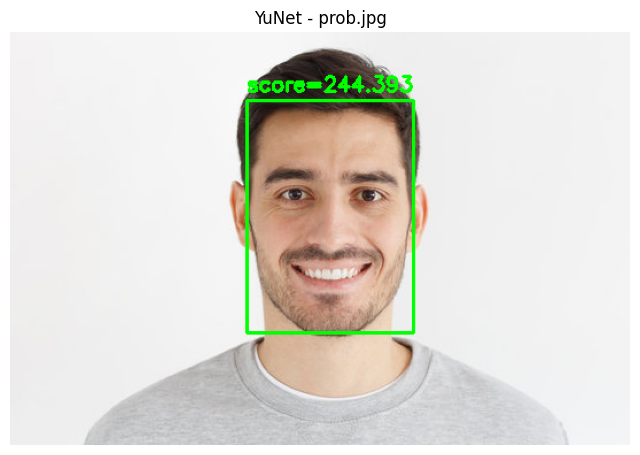

In [19]:
# Exemplo de uso do detector
test_img_path = TEST_DIR / "prob.jpg"

if test_img_path.exists():
    img = read_image(str(test_img_path))
    faces = detect_faces(img)
    print(f"Faces detectadas: {len(faces)}")
    draw_faces(img, faces, title=f"YuNet - {test_img_path.name}")
else:
    print(f"Coloque uma imagem em: {test_img_path}")

## 2) Identificação facial (SFace)

> Estratégia: criar uma base de embeddings por cliente e comparar por similaridade de cosseno.

### Formato sugerido da base `data/enroll/`
- `data/enroll/cliente_001/img1.jpg`
- `data/enroll/cliente_001/img2.jpg`
- `data/enroll/cliente_002/img1.jpg`

In [10]:
def get_face_embedding(img_bgr: np.ndarray):
    faces = detect_faces(img_bgr)
    if len(faces) == 0:
        return None, None
    face = faces[0].astype(np.float32)
    aligned = recognizer.alignCrop(img_bgr, face)
    feat = recognizer.feature(aligned)
    return feat, face

def cosine_similarity(f1, f2):
    # Match usa comparação de cosseno quando dis_type=0
    return float(recognizer.match(f1, f2, cv2.FaceRecognizerSF_FR_COSINE))

def build_gallery(enroll_root: Path):
    gallery = {}
    if not enroll_root.exists():
        return gallery

    for person_dir in sorted([p for p in enroll_root.iterdir() if p.is_dir()]):
        person_id = person_dir.name
        feats = []
        for img_path in person_dir.glob("*.jpg"):
            img = read_image(str(img_path))
            feat, face = get_face_embedding(img)
            if feat is not None:
                feats.append(feat)
        if feats:
            gallery[person_id] = feats
    return gallery

def identify_person(probe_img_bgr: np.ndarray, gallery: dict, threshold: float = 0.35):
    probe_feat, probe_face = get_face_embedding(probe_img_bgr)
    if probe_feat is None:
        return {"status": "NO_FACE", "best_id": None, "score": 0.0, "face": None}

    best_id = None
    best_score = -1.0

    for person_id, feat_list in gallery.items():
        scores = [cosine_similarity(probe_feat, f) for f in feat_list]
        person_score = max(scores) if scores else -1.0
        if person_score > best_score:
            best_score = person_score
            best_id = person_id

    status = "MATCH" if best_score >= threshold else "NO_MATCH"
    return {
        "status": status,
        "best_id": best_id,
        "score": float(best_score),
        "face": probe_face,
    }

In [11]:
# Construção da galeria e teste de identificação
gallery = build_gallery(ENROLL_DIR)
print(f"Clientes cadastrados: {len(gallery)} -> {list(gallery.keys())[:10]}")

probe_path = TEST_DIR / "probe.jpg"
if probe_path.exists() and gallery:
    probe = read_image(str(probe_path))
    result = identify_person(probe, gallery, threshold=0.35)
    print("Resultado identificação:", {k: v for k, v in result.items() if k != "face"})

    vis = probe.copy()
    if result["face"] is not None:
        x, y, w, h = map(int, result["face"][:4])
        color = (0, 255, 0) if result["status"] == "MATCH" else (0, 0, 255)
        text = f"{result['best_id']} | score={result['score']:.3f} | {result['status']}"
        cv2.rectangle(vis, (x, y), (x+w, y+h), color, 2)
        cv2.putText(vis, text, (x, max(20, y-8)), cv2.FONT_HERSHEY_SIMPLEX, 0.55, color, 2)

    plt.figure(figsize=(8, 6))
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title("Identificação facial")
    plt.show()
else:
    print(f"Garanta dados em {ENROLL_DIR} e uma imagem de teste em {probe_path}")

Clientes cadastrados: 0 -> []
Garanta dados em /content/data/enroll e uma imagem de teste em /content/data/test/probe.jpg


## 2.1) Cadastro de cliente via webcam ou upload

> Execute esta célula para **cadastrar um novo cliente**. Altere `CLIENTE_ID`, `N_FOTOS` e `MODO` conforme necessário.

| Variável | Opções | Descrição |
|---|---|---|
| `CLIENTE_ID` | string | Identificador único do cliente (ex.: `"cliente_001"`) |
| `N_FOTOS` | inteiro | Número de fotos para o cadastro (recomendado: 3 a 5) |
| `MODO` | `"webcam"` ou `"upload"` | Fonte das imagens |

- **`"webcam"`**: ativa a câmera do navegador — clique em "Capturar Foto" para cada imagem.
- **`"upload"`**: abre o seletor de arquivos — escolha uma foto JPG/PNG por vez.

As fotos são salvas em `data/enroll/{CLIENTE_ID}/imgN.jpg` e usadas para construir a galeria de embeddings.


📋 Cadastrando cliente: cliente_003
   Modo: upload | 2 fotos serão capturadas
   Faça upload de fotos diferentes do mesmo cliente (frente, leve ângulo, etc.).

--- Foto 1/2 ---
📁 Selecione uma foto (JPG/PNG) para identificação...


Saving 3x4.JPEG to 3x4.JPEG
✅ Foto salva em: /content/data/enroll/cliente_003/img1.jpg
⚠️  Nenhuma face detectada na foto 1. Tente com melhor iluminação.


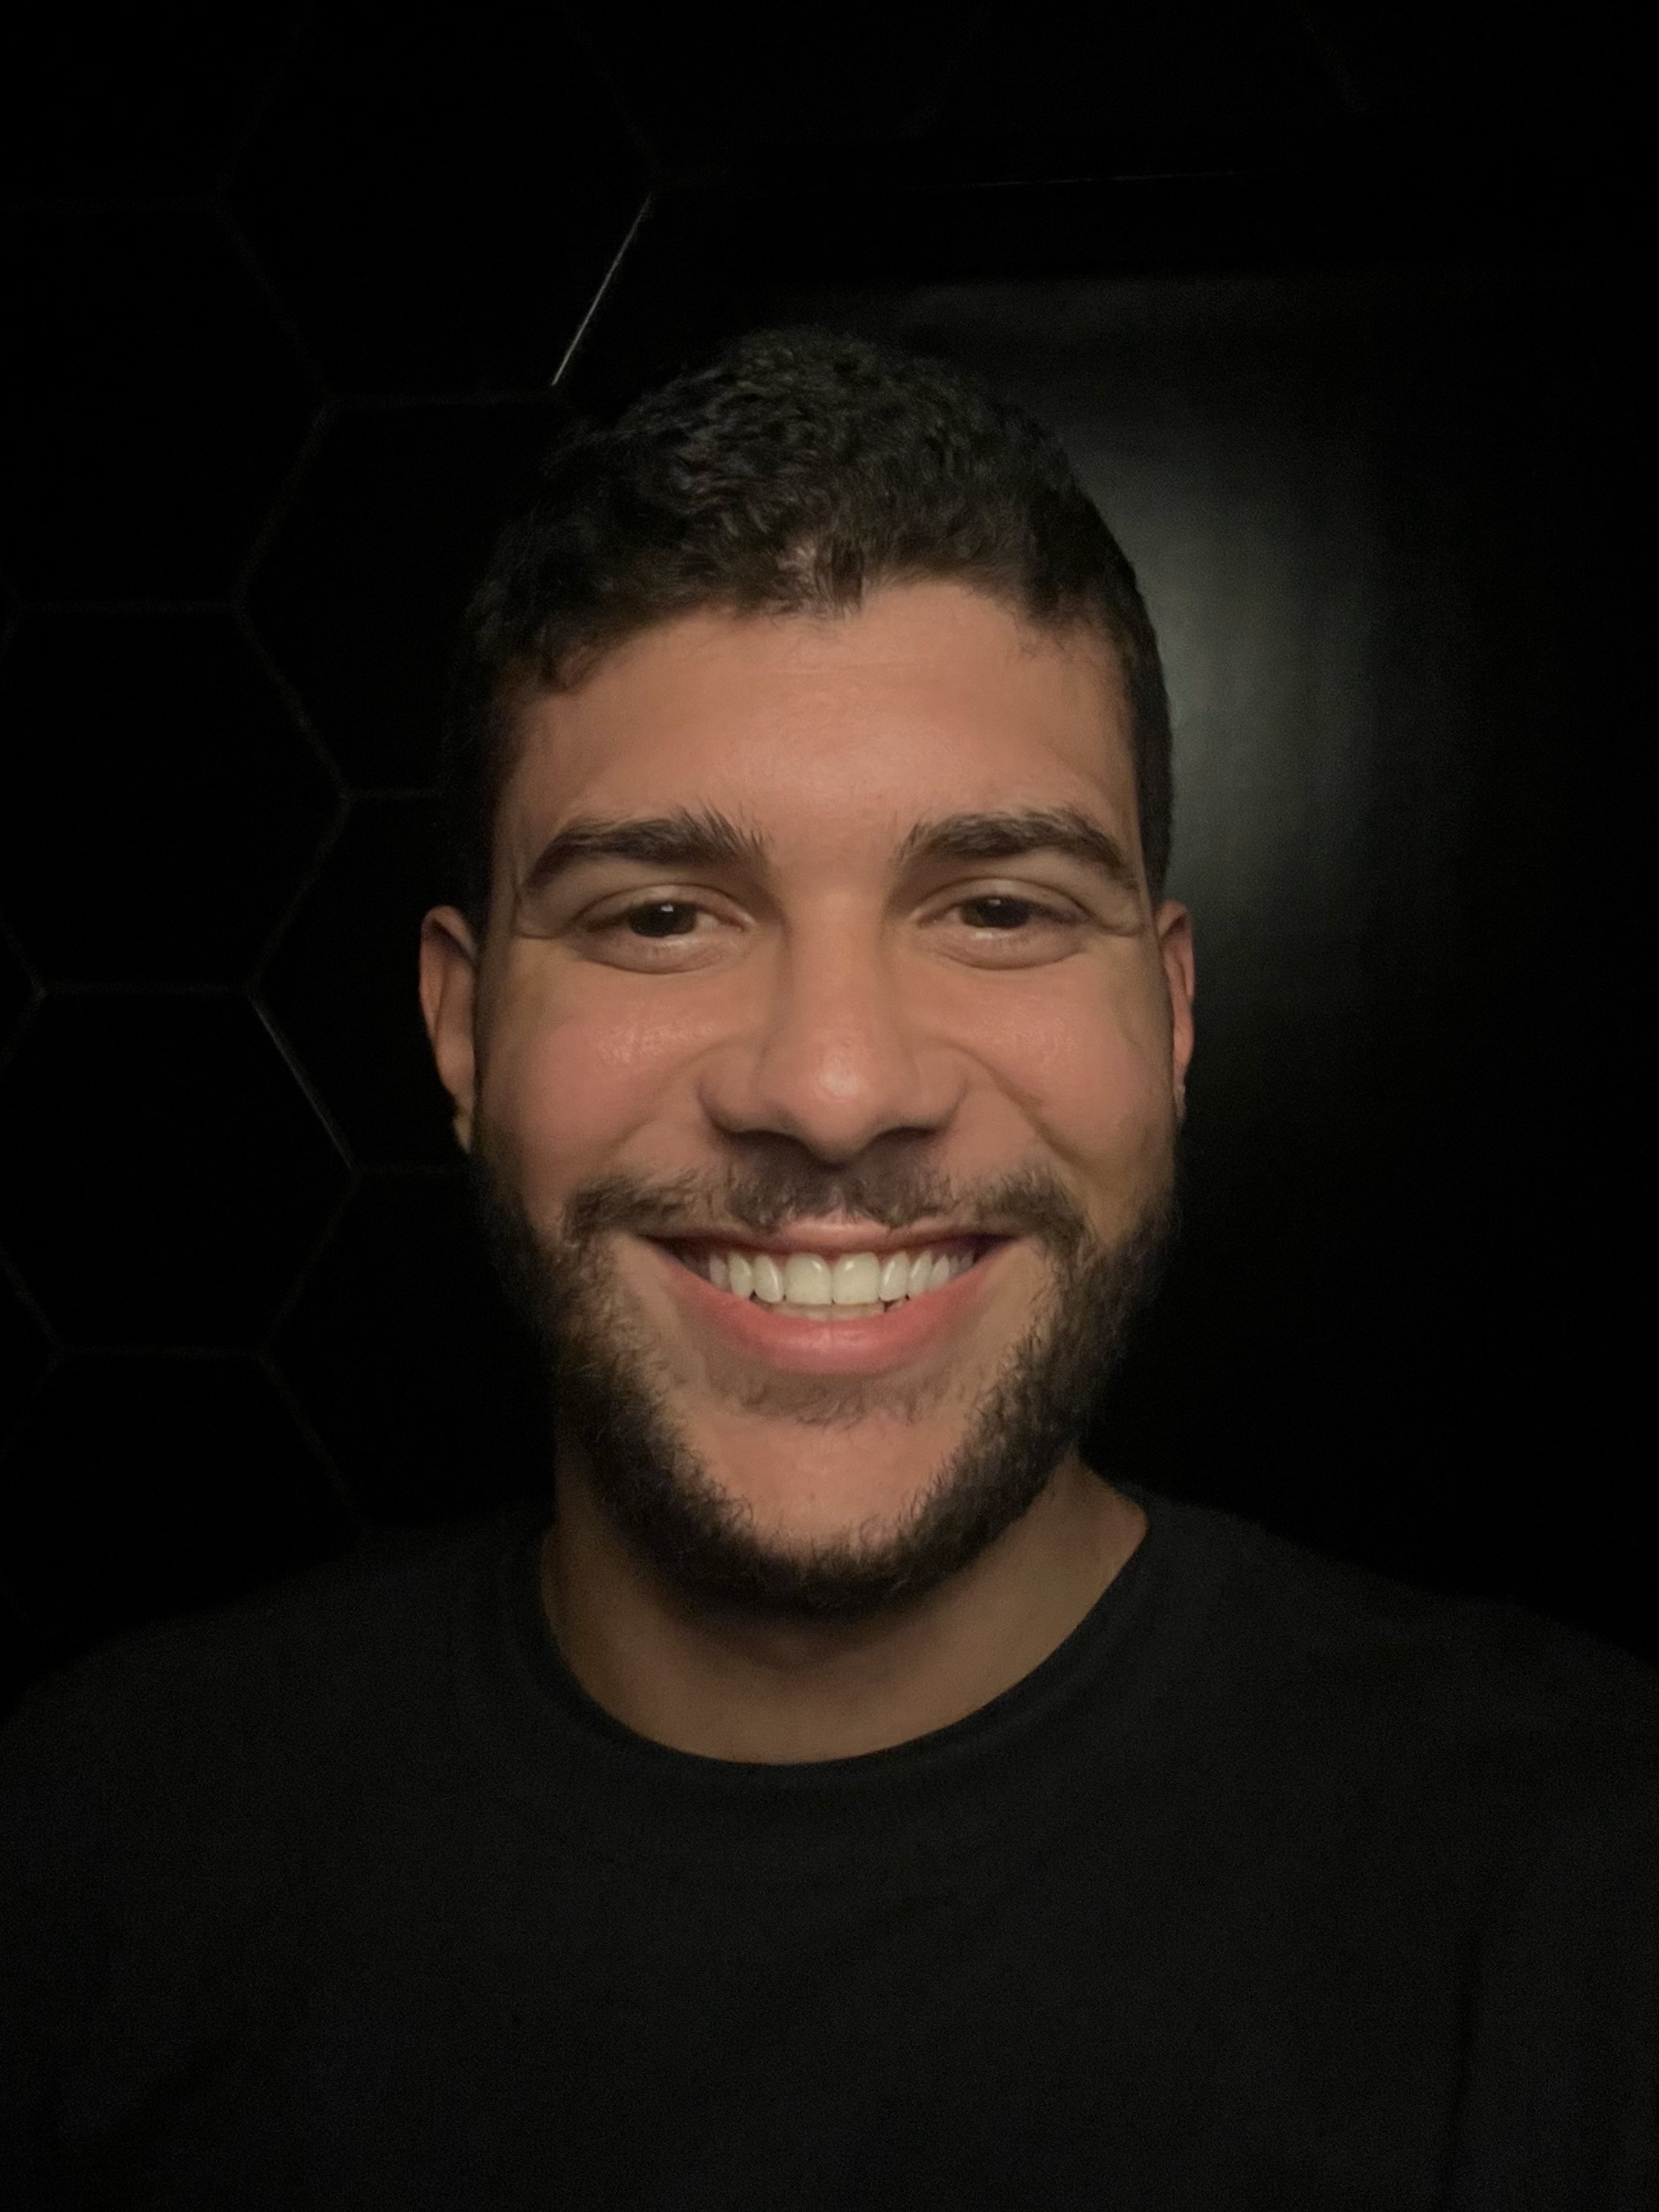

--- Foto 2/2 ---
📁 Selecione uma foto (JPG/PNG) para identificação...


Saving PERFIL_SEMCRACHA.png to PERFIL_SEMCRACHA.png
✅ Foto salva em: /content/data/enroll/cliente_003/img2.jpg
✅ Face detectada (score=294.174)


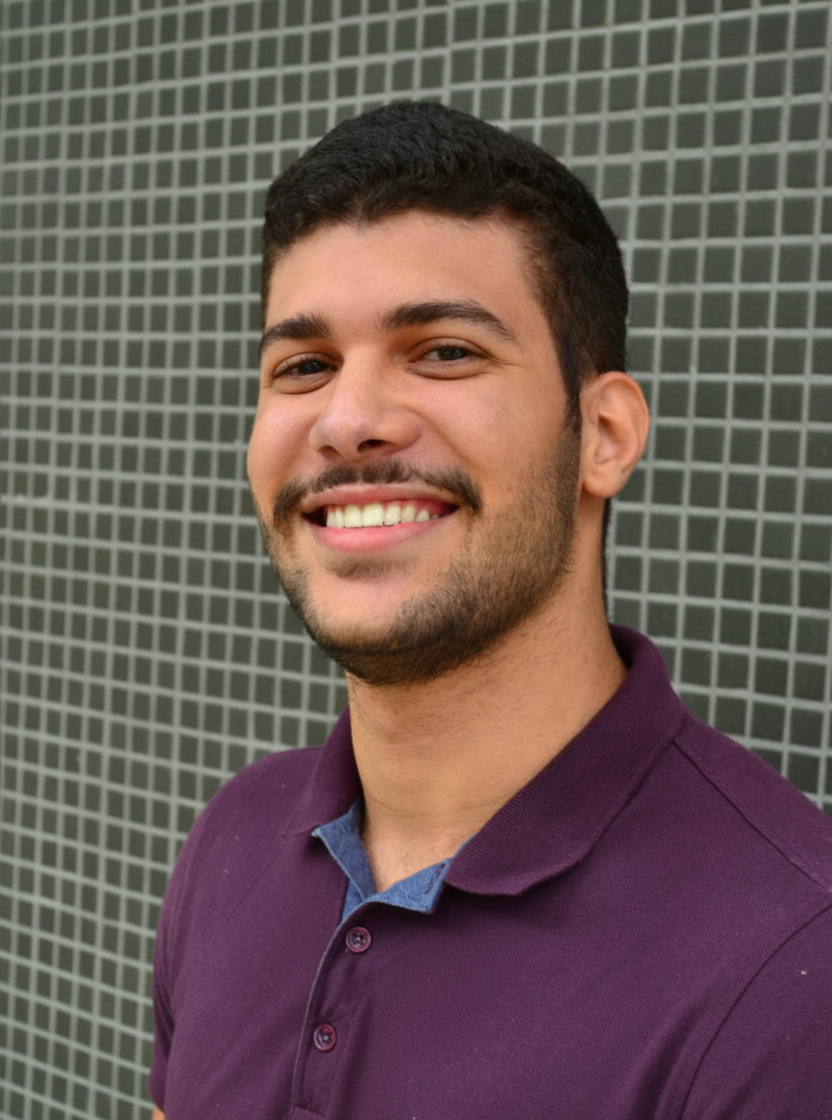


✅ Cadastro de 'cliente_003' concluído! → /content/data/enroll/cliente_003


In [18]:
# ============================================================
# Cadastro de cliente (Enrollment)
#
# MODO = "webcam"  → captura fotos via câmera do navegador
# MODO = "upload"  → faz upload de fotos salvas no seu dispositivo
#
# Altere CLIENTE_ID, N_FOTOS e MODO antes de executar.
# ============================================================
import IPython.display as display
from IPython.display import Image as IPyImage

# ← Ajuste aqui
CLIENTE_ID = "cliente_003"
N_FOTOS    = 2       # recomendado: 3 a 5
MODO       = "upload"  # "webcam" ou "upload"

enroll_dir_cliente = ENROLL_DIR / CLIENTE_ID
enroll_dir_cliente.mkdir(parents=True, exist_ok=True)

print(f"📋 Cadastrando cliente: {CLIENTE_ID}")
print(f"   Modo: {MODO} | {N_FOTOS} fotos serão capturadas")
if MODO == "webcam":
    print("   Mude levemente a posição/inclinação entre cada foto.\n")
else:
    print("   Faça upload de fotos diferentes do mesmo cliente (frente, leve ângulo, etc.).\n")

for i in range(1, N_FOTOS + 1):
    print(f"--- Foto {i}/{N_FOTOS} ---")
    path = str(enroll_dir_cliente / f"img{i}.jpg")

    if MODO == "webcam":
        take_photo(path)
    else:
        upload_photo(path)

    img   = cv2.imread(path)
    faces = detect_faces(img)
    if len(faces) == 0:
        print(f"⚠️  Nenhuma face detectada na foto {i}. Tente com melhor iluminação.")
    else:
        print(f"✅ Face detectada (score={float(faces[0][4]):.3f})")

    display.display(IPyImage(path, width=300))

print(f"\n✅ Cadastro de '{CLIENTE_ID}' concluído! → {enroll_dir_cliente}")


## 3) Detecção de vivacidade (Liveness)

> Objetivo: bloquear fraude com **foto estática**. Um fraudador pode tentar se autenticar segurando a foto do cliente legítimo — o liveness detecta isso.

### Técnica: EAR (Eye Aspect Ratio) com FaceLandmarker Tasks API

Seguindo o padrão do professor, usamos o modelo **`face_landmarker.task`** da MediaPipe com a nova **Tasks API** (`mediapipe.tasks.python.vision.FaceLandmarker`).

O modelo retorna **478 landmarks faciais** de alta precisão. Calculamos o EAR para cada olho:

$$EAR = \frac{\|p_2 - p_6\| + \|p_3 - p_5\|}{2 \cdot \|p_1 - p_4\|}$$

- $EAR < \text{threshold}$ → olho **fechado**
- $EAR \geq \text{threshold}$ → olho **aberto**
- Transição fechado → aberto = **piscada contabilizada**

### Por que foto estática falha?
Uma foto não pisca — o EAR permanece constante (olho sempre "aberto"), então `blink_count = 0` → `is_live = False` → `EM_REVISAO`.


In [21]:
!pip install mediapipe==0.10.31

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 131.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 17.1 MB/s eta 0:00:00
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0


In [22]:
import cv2
import mediapipe as mp
import matplotlib.pyplot as plt
from moviepy.editor import VideoFileClip

/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:294: SyntaxWarning: invalid escape sequence '\d'
  lines_video = [l for l in lines if ' Video: ' in l and re.search('\d+x\d+', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:367: SyntaxWarning: invalid escape sequence '\d'
  rotation_lines = [l for l in lines if 'rotate          :' in l and re.search('\d+$', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:370: SyntaxWarning: invalid escape sequence '\d'
  match = re.search('\d+$', rotation_line)
  if event.key is 'enter':



In [24]:
from google.colab.patches import cv2_imshow

BaseOptions           = mp.tasks.BaseOptions
FaceLandmarker        = mp.tasks.vision.FaceLandmarker
FaceLandmarkerOptions = mp.tasks.vision.FaceLandmarkerOptions
VisionRunningMode     = mp.tasks.vision.RunningMode

In [25]:
# ============================================================
# 3) Detecção de vivacidade (Liveness) — FaceLandmarker Tasks API
#
# Abordagem: EAR (Eye Aspect Ratio) para detectar piscadas.
# Usa o modelo face_landmarker.task (padrão do professor — aula 4),
# com a Tasks API do MediaPipe no modo VIDEO (detect_for_video),
# que mantém tracking temporal entre frames — igual ao professor
# usa para processamento de sequências de vídeo.
#
# EAR < threshold  → olho fechado
# EAR >= threshold → olho aberto
# Piscada = transição fechado → aberto
# ============================================================

# Índices dos pontos dos olhos no modelo FaceLandmarker (478 landmarks)
# Mapeamento padrão MediaPipe para EAR: [P1, P2, P3, P4, P5, P6]
#   P1=canto interno, P4=canto externo, P2/P3=superior, P5/P6=inferior
LEFT_EYE_IDX  = [33, 160, 158, 133, 153, 144]
RIGHT_EYE_IDX = [362, 385, 387, 263, 373, 380]


def euclid(a, b):
    """Distância euclidiana — equivalente a scipy.spatial.distance.euclidean."""
    return dist.euclidean(a, b)


def eye_aspect_ratio(pts):
    """
    EAR (Eye Aspect Ratio) — Soukupová & Čech (2016).

    EAR = (||p2-p6|| + ||p3-p5||) / (2 * ||p1-p4||)

    Quanto menor o valor, mais fechado está o olho.
    """
    p1, p2, p3, p4, p5, p6 = pts
    a = euclid(p2, p6)
    b = euclid(p3, p5)
    c = euclid(p1, p4)
    return (a + b) / (2.0 * c + 1e-8)


def liveness_blink_from_frames(
    frames_bgr: list,
    ear_threshold: float = 0.20,
    min_blinks: int = 1,
    fps: float = 30.0
) -> dict:
    """
    Detecta piscadas em uma sequência de frames BGR usando o
    FaceLandmarker da MediaPipe Tasks API no modo VIDEO.

    Seguindo o padrão do professor (aula 4), utiliza VisionRunningMode.VIDEO
    com detect_for_video() e timestamps monotônicos crescentes, garantindo
    tracking temporal correto entre os frames.

    Parâmetros:
        frames_bgr    : lista de frames numpy BGR
        ear_threshold : EAR abaixo desse valor = olho fechado
        min_blinks    : mínimo de piscadas para considerar vivo
        fps           : frames por segundo estimado (para calcular timestamps)

    Retorna dict: is_live, blink_count, ear_mean, ear_min
    """
    if not frames_bgr:
        return {"is_live": False, "blink_count": 0, "ear_mean": 0.0, "ear_min": 0.0}

    options = FaceLandmarkerOptions(
        base_options=BaseOptions(model_asset_path=str(LANDMARKER_PATH)),
        running_mode=VisionRunningMode.VIDEO,   # modo vídeo: detect_for_video()
        num_faces=1,
        min_face_detection_confidence=0.5,
        min_face_presence_confidence=0.5,
        min_tracking_confidence=0.5,
        output_face_blendshapes=False,
        output_facial_transformation_matrixes=False,
    )

    blink_count, was_closed = 0, False
    ear_values = []
    frame_interval_ms = int(1000.0 / fps)   # intervalo em ms entre frames

    with FaceLandmarker.create_from_options(options) as landmarker:
        for frame_idx, frame in enumerate(frames_bgr):
            rgb    = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)

            # detect_for_video exige timestamp em ms (deve ser monotônico crescente)
            timestamp_ms = frame_idx * frame_interval_ms
            result       = landmarker.detect_for_video(mp_img, timestamp_ms)

            if not result.face_landmarks:
                continue

            h, w  = frame.shape[:2]
            lm    = result.face_landmarks[0]

            left_pts  = [(lm[i].x * w, lm[i].y * h) for i in LEFT_EYE_IDX]
            right_pts = [(lm[i].x * w, lm[i].y * h) for i in RIGHT_EYE_IDX]

            ear = (eye_aspect_ratio(left_pts) + eye_aspect_ratio(right_pts)) / 2.0
            ear_values.append(float(ear))

            if ear < ear_threshold and not was_closed:
                was_closed = True
            elif ear >= ear_threshold and was_closed:
                blink_count += 1
                was_closed   = False

    is_live = blink_count >= min_blinks
    return {
        "is_live":     bool(is_live),
        "blink_count": int(blink_count),
        "ear_mean":    float(np.mean(ear_values)) if ear_values else 0.0,
        "ear_min":     float(np.min(ear_values))  if ear_values else 0.0,
    }


# ── Teste rápido de sanidade com lista vazia ────────────────
_test = liveness_blink_from_frames([])
print("FaceLandmarker Tasks API carregado com sucesso.")
print(f"Teste (frames vazios): {_test}")


FaceLandmarker Tasks API carregado com sucesso.
Teste (frames vazios): {'is_live': False, 'blink_count': 0, 'ear_mean': 0.0, 'ear_min': 0.0}


Clientes na galeria: ['cliente_001', 'cliente_002', 'cliente_003']

📷 PASSO 1/2 — Captura para IDENTIFICAÇÃO
   Olhe diretamente para a câmera e clique em 'Capturar Foto'.


<IPython.core.display.Javascript object>

📷 Foto salva em: /content/data/test/probe.jpg

👁  PASSO 2/2 — Captura para LIVENESS (detecção de piscada via EAR)
   Aguarde a contagem regressiva e PISCE os olhos durante a gravação.


<IPython.core.display.Javascript object>

✅ 25 frames capturados para liveness.

{
  "timestamp": "2026-05-22T22:07:43.788396",
  "decision": "APROVADO",
  "reason": "Identidade confirmada e liveness aprovado.",
  "identificacao": {
    "status": "MATCH",
    "best_id": "cliente_003",
    "score": 0.6404098486316343,
    "threshold": 0.35
  },
  "liveness": {
    "is_live": true,
    "blink_count": 2,
    "ear_mean": 0.29733832049045944,
    "ear_min": 0.16307484902826985
  }
}


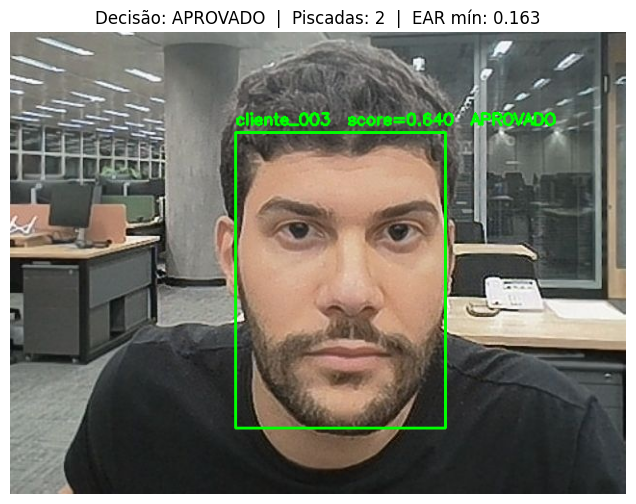


📁 Evidência salva:
   Imagem   : /content/evidencias/auth_20260522_220744.jpg
   Metadados: /content/evidencias/auth_20260522_220744.json


In [27]:
# ============================================================
# Funções de decisão e salvamento de evidências
# ============================================================

def save_evidence(probe_img_bgr, decision_payload: dict, prefix: str = "tentativa"):
    ts        = datetime.now().strftime("%Y%m%d_%H%M%S")
    img_path  = EVIDENCE_DIR / f"{prefix}_{ts}.jpg"
    meta_path = EVIDENCE_DIR / f"{prefix}_{ts}.json"
    cv2.imwrite(str(img_path), probe_img_bgr)
    with open(meta_path, "w", encoding="utf-8") as f:
        json.dump(decision_payload, f, ensure_ascii=False, indent=2)
    return str(img_path), str(meta_path)


def auth_decision(probe_img_bgr, gallery: dict, liveness_result: dict, id_threshold: float = 0.35) -> dict:
    """
    Executa o pipeline completo de autenticação:
      1. Comparação facial: extrai embedding da imagem sonda e compara com a
         galeria por similaridade de cosseno (SFace).
      2. Liveness: verifica se foram detectadas piscadas suficientes.
      3. Decisão: APROVADO apenas se ambas as verificações passarem.
    """
    id_result = identify_person(probe_img_bgr, gallery, threshold=id_threshold)
    approved  = (id_result["status"] == "MATCH") and liveness_result.get("is_live", False)

    return {
        "timestamp":  datetime.now().isoformat(),
        "decision":   "APROVADO" if approved else "EM_REVISAO",
        "reason":     (
            "Identidade confirmada e liveness aprovado."
            if approved else
            "Falha na identificação facial ou na detecção de vivacidade."
        ),
        "identificacao": {
            "status":    id_result["status"],
            "best_id":   id_result["best_id"],
            "score":     id_result["score"],
            "threshold": id_threshold,
        },
        "liveness": liveness_result,
    }


# ============================================================
# Fluxo completo de autenticação
#
# MODO_ID       = "webcam" ou "upload"  → captura da foto de identificação
# MODO_LIVENESS = "webcam" ou "upload"  → captura de frames para liveness
#
# Altere os modos abaixo antes de executar.
# ============================================================

MODO_ID       = "webcam"   # "webcam" ou "upload"
MODO_LIVENESS = "webcam"   # "webcam" ou "upload"

gallery = build_gallery(ENROLL_DIR)
print(f"Clientes na galeria: {list(gallery.keys())}")

if not gallery:
    print("\n⚠️  Galeria vazia! Execute a célula de cadastro (seção 2.1) antes de autenticar.")
else:
    # ── PASSO 1: Captura foto de identificação ───────────────────
    print("\n📷 PASSO 1/2 — Captura para IDENTIFICAÇÃO")
    probe_path_tmp = str(TEST_DIR / "probe.jpg")

    if MODO_ID == "webcam":
        print("   Olhe diretamente para a câmera e clique em 'Capturar Foto'.")
        take_photo(probe_path_tmp)
    else:
        print("   Faça upload de uma foto sua para identificação.")
        upload_photo(probe_path_tmp)

    probe = read_image(probe_path_tmp)

    # ── PASSO 2: Captura de frames para liveness ─────────────────
    print("\n👁  PASSO 2/2 — Captura para LIVENESS (detecção de piscada via EAR)")

    if MODO_LIVENESS == "webcam":
        print("   Aguarde a contagem regressiva e PISCE os olhos durante a gravação.")
        frames_liveness = capture_frames(n_frames=25, interval_ms=150)
    else:
        print("   Envie um vídeo curto (2-4 s) onde você pisce pelo menos uma vez.")
        frames_liveness = upload_video_and_extract_frames(max_frames=40)

    if not frames_liveness:
        print("⚠️  Nenhum frame capturado. Tente novamente.")
    else:
        # ── PASSO 3: Pipeline de decisão ─────────────────────────
        live_result      = liveness_blink_from_frames(frames_liveness, ear_threshold=0.20, min_blinks=1)
        decision_payload = auth_decision(probe, gallery, live_result, id_threshold=0.35)

        # ── Exibe resultado completo ───────────────────────────────
        print("\n" + "=" * 60)
        print(json.dumps(decision_payload, ensure_ascii=False, indent=2))
        print("=" * 60)

        # ── Visualização com bounding box e veredito ──────────────
        vis        = probe.copy()
        id_res     = decision_payload["identificacao"]
        face_res   = identify_person(probe, gallery)
        if face_res["face"] is not None:
            x, y, w, h = map(int, face_res["face"][:4])
            color  = (0, 255, 0) if decision_payload["decision"] == "APROVADO" else (0, 0, 255)
            label  = (
                f"{id_res['best_id']}  score={id_res['score']:.3f}  "
                f"{decision_payload['decision']}"
            )
            cv2.rectangle(vis, (x, y), (x + w, y + h), color, 2)
            cv2.putText(vis, label, (x, max(20, y - 8)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.55, color, 2)

        plt.figure(figsize=(8, 6))
        plt.title(
            f"Decisão: {decision_payload['decision']}  |  "
            f"Piscadas: {live_result['blink_count']}  |  "
            f"EAR mín: {live_result['ear_min']:.3f}"
        )
        plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
        plt.axis("off")
        plt.show()

        # ── Salva evidências para auditoria ───────────────────────
        img_evd, json_evd = save_evidence(probe, decision_payload, prefix="auth")
        print(f"\n📁 Evidência salva:")
        print(f"   Imagem   : {img_evd}")
        print(f"   Metadados: {json_evd}")


## 4) Ajuste de limiares e governança (essencial para produção)

> Use uma base de validação separada e ajuste os limiares para equilibrar segurança e fricção.

- `threshold_identificacao`: aumente para reduzir falso aceite (fraude), diminua para reduzir falso bloqueio.
- `ear_threshold` e `min_blinks`: calibrar por câmera/dispositivo e perfil de usuário.
- Logar tentativas em `evidencias/` para auditoria, explicabilidade e retreino.
- Em serviços críticos (ex.: crédito), exigir **2 fatores**: senha + face + liveness ativo.

### Próximo passo recomendado
1. Testar com no mínimo 30 clientes reais (com consentimento).
2. Medir FAR/FRR e EER.
3. Definir limiar operacional por risco do produto (crédito > transferência > consulta).